# AAPL Stock Trend Analysis

#Introduction
This project analyzes historical Apple Inc. (AAPL) stock prices to understand price trends, trading behavior, seasonality, anomalies, and short-term fluctuations. The analysis includes data preprocessing, exploratory data analysis, time-series trend analysis, seasonal pattern analysis, anomaly detection, moving averages, and forecasting using Prophet and ARIMA. The goal is to extract meaningful insights from historical stock data and demonstrate practical time-series analysis techniques.

### 1. Data Loading and Preparation
### 2. Exploratory Data Analysis
### 3. Time Series Trend Analysis
### 4. Seasonality Analysis
### 5. Anomaly Detection
### 6. Moving Average Analysis
### 7. Forecasting with Prophet and ARIMA
### 8. Model Evaluation and Comparison
### 9. Final Forecast Visualization

## Importing Libraries
Import the Python libraries required for data analysis, visualization, and forecasting.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
from google.colab import files

uploaded = files.upload()


Saving AAPL.csv to AAPL.csv


#Data Loading and Preparation

## Load the Dataset
Load the historical AAPL stock dataset into a pandas DataFrame.

In [ ]:
df = pd.read_csv("AAPL.csv")

df.head()

,Unnamed: 0,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,0,AAPL,2015-05-27 00:00:00+00:00,132.045,132.260,130.05,130.34,45833246,121.682558,121.880685,119.844118,120.111360,45833246,0.0,1.0
1,1,AAPL,2015-05-28 00:00:00+00:00,131.780,131.950,131.10,131.86,30733309,121.438354,121.595013,120.811718,121.512076,30733309,0.0,1.0
2,2,AAPL,2015-05-29 00:00:00+00:00,130.280,131.450,129.90,131.23,50884452,120.056069,121.134251,119.705890,120.931516,50884452,0.0,1.0
3,3,AAPL,2015-06-01 00:00:00+00:00,130.535,131.390,130.05,131.20,32112797,120.291057,121.078960,119.844118,120.903870,32112797,0.0,1.0
4,4,AAPL,2015-06-02 00:00:00+00:00,129.960,130.655,129.32,129.86,33667627,119.761181,120.401640,119.171406,119.669029,33667627,0.0,1.0


In [ ]:
df.tail()

,Unnamed: 0,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
1253,1253,AAPL,2020-05-18 00:00:00+00:00,314.96,316.50,310.3241,313.17,33843125,314.96,316.50,310.3241,313.17,33843125,0.0,1.0
1254,1254,AAPL,2020-05-19 00:00:00+00:00,313.14,318.52,313.0100,315.03,25432385,313.14,318.52,313.0100,315.03,25432385,0.0,1.0
1255,1255,AAPL,2020-05-20 00:00:00+00:00,319.23,319.52,316.2000,316.68,27876215,319.23,319.52,316.2000,316.68,27876215,0.0,1.0
1256,1256,AAPL,2020-05-21 00:00:00+00:00,316.85,320.89,315.8700,318.66,25672211,316.85,320.89,315.8700,318.66,25672211,0.0,1.0
1257,1257,AAPL,2020-05-22 00:00:00+00:00,318.89,319.23,315.3500,315.77,20450754,318.89,319.23,315.3500,315.77,20450754,0.0,1.0


In [ ]:
# Remove the unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

In [ ]:
df.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,AAPL,2015-05-27 00:00:00+00:00,132.045,132.260,130.05,130.34,45833246,121.682558,121.880685,119.844118,120.111360,45833246,0.0,1.0
1,AAPL,2015-05-28 00:00:00+00:00,131.780,131.950,131.10,131.86,30733309,121.438354,121.595013,120.811718,121.512076,30733309,0.0,1.0
2,AAPL,2015-05-29 00:00:00+00:00,130.280,131.450,129.90,131.23,50884452,120.056069,121.134251,119.705890,120.931516,50884452,0.0,1.0
3,AAPL,2015-06-01 00:00:00+00:00,130.535,131.390,130.05,131.20,32112797,120.291057,121.078960,119.844118,120.903870,32112797,0.0,1.0
4,AAPL,2015-06-02 00:00:00+00:00,129.960,130.655,129.32,129.86,33667627,119.761181,120.401640,119.171406,119.669029,33667627,0.0,1.0


## Inspection of the Dataset
Check the dataset structure, columns, data types, dimensions, and overall contents.

In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (1258, 14)

Columns:
['symbol', 'date', 'close', 'high', 'low', 'open', 'volume', 'adjClose', 'adjHigh', 'adjLow', 'adjOpen', 'adjVolume', 'divCash', 'splitFactor']

Data Types:
symbol          object
date            object
close          float64
high           float64
low            float64
open           float64
volume           int64
adjClose       float64
adjHigh        float64
adjLow         float64
adjOpen        float64
adjVolume        int64
divCash        float64
splitFactor    float64
dtype: object

Missing Values:
symbol         0
date           0
close          0
high           0
low            0
open           0
volume         0
adjClose       0
adjHigh        0
adjLow         0
adjOpen        0
adjVolume      0
divCash        0
splitFactor    0
dtype: int64


## Duplicate Records
Check for duplicate rows to ensure that each stock record is unique.

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1258 entries, 0 to 1257
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   symbol       1258 non-null   object 
 1   date         1258 non-null   object 
 2   close        1258 non-null   float64
 3   high         1258 non-null   float64
 4   low          1258 non-null   float64
 5   open         1258 non-null   float64
 6   volume       1258 non-null   int64  
 7   adjClose     1258 non-null   float64
 8   adjHigh      1258 non-null   float64
 9   adjLow       1258 non-null   float64
 10  adjOpen      1258 non-null   float64
 11  adjVolume    1258 non-null   int64  
 12  divCash      1258 non-null   float64
 13  splitFactor  1258 non-null   float64
dtypes: float64(10), int64(2), object(2)
memory usage: 137.7+ KB


## Statistical Summary
Generate descriptive statistics to understand the distribution and range of numerical variables.

In [ ]:
df.describe()

,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03,1258.000000,1258.0
mean,167.723998,169.230475,166.039780,167.548266,3.500397e+07,162.666715,164.131054,161.028013,162.493082,3.500397e+07,0.010477,1.0
std,56.850796,57.500128,56.006773,56.612707,1.729100e+07,58.733820,59.402842,57.869246,58.494560,1.729100e+07,0.083366,0.0
min,90.340000,91.670000,89.470000,90.000000,1.136204e+07,84.954351,86.205062,84.136216,84.634620,1.136204e+07,0.000000,1.0
25%,116.327500,117.405000,115.602500,116.482500,2.359205e+07,109.484490,110.393556,107.962457,109.135002,2.359205e+07,0.000000,1.0
50%,160.485000,162.080000,158.974250,160.345000,3.064771e+07,154.710645,156.091874,153.054341,154.410017,3.064771e+07,0.000000,1.0
75%,199.785000,201.277500,198.170000,199.520000,4.100487e+07,196.960053,198.428438,195.281553,196.452903,4.100487e+07,0.000000,1.0
max,327.200000,327.850000,323.350000,324.730000,1.622063e+08,326.337147,326.357095,322.497300,323.873661,1.622063e+08,0.820000,1.0


## Converting Date
Convert the date column into datetime format so it can be used for time-series analysis.

In [ ]:
# Convert date to datetime
df["date"] = pd.to_datetime(df["date"])

df = df.sort_values("date")

df.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,AAPL,2015-05-27 00:00:00+00:00,132.045,132.260,130.05,130.34,45833246,121.682558,121.880685,119.844118,120.111360,45833246,0.0,1.0
1,AAPL,2015-05-28 00:00:00+00:00,131.780,131.950,131.10,131.86,30733309,121.438354,121.595013,120.811718,121.512076,30733309,0.0,1.0
2,AAPL,2015-05-29 00:00:00+00:00,130.280,131.450,129.90,131.23,50884452,120.056069,121.134251,119.705890,120.931516,50884452,0.0,1.0
3,AAPL,2015-06-01 00:00:00+00:00,130.535,131.390,130.05,131.20,32112797,120.291057,121.078960,119.844118,120.903870,32112797,0.0,1.0
4,AAPL,2015-06-02 00:00:00+00:00,129.960,130.655,129.32,129.86,33667627,119.761181,120.401640,119.171406,119.669029,33667627,0.0,1.0


In [ ]:
print("Start Date:", df["date"].min())
print("End Date:", df["date"].max())

Start Date: 2015-05-27 00:00:00+00:00
End Date: 2020-05-22 00:00:00+00:00


In [ ]:
df.isnull().sum()

,0
symbol,0
date,0
close,0
high,0
low,0
open,0
volume,0
adjClose,0
adjHigh,0
adjLow,0


In [ ]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage


,0
symbol,0.0
date,0.0
close,0.0
high,0.0
low,0.0
open,0.0
volume,0.0
adjClose,0.0
adjHigh,0.0
adjLow,0.0


## Sorting by Date
Sort the stock records chronologically to maintain the correct time-series order.

In [ ]:
df = df.sort_values("date").reset_index(drop=True)

In [ ]:
df.head()

,symbol,date,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
0,AAPL,2015-05-27 00:00:00+00:00,132.045,132.260,130.05,130.34,45833246,121.682558,121.880685,119.844118,120.111360,45833246,0.0,1.0
1,AAPL,2015-05-28 00:00:00+00:00,131.780,131.950,131.10,131.86,30733309,121.438354,121.595013,120.811718,121.512076,30733309,0.0,1.0
2,AAPL,2015-05-29 00:00:00+00:00,130.280,131.450,129.90,131.23,50884452,120.056069,121.134251,119.705890,120.931516,50884452,0.0,1.0
3,AAPL,2015-06-01 00:00:00+00:00,130.535,131.390,130.05,131.20,32112797,120.291057,121.078960,119.844118,120.903870,32112797,0.0,1.0
4,AAPL,2015-06-02 00:00:00+00:00,129.960,130.655,129.32,129.86,33667627,119.761181,120.401640,119.171406,119.669029,33667627,0.0,1.0


In [ ]:
# Verify the stock symbol
df["symbol"].unique()

array(['AAPL'], dtype=object)

#Exploratory Data Analysis (EDA)

Explore stock prices, trading volume, daily price range, and relationships between numerical variables.

In [ ]:
df.describe()

,close,high,low,open,volume,adjClose,adjHigh,adjLow,adjOpen,adjVolume,divCash,splitFactor
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03,1258.000000,1258.0
mean,167.723998,169.230475,166.039780,167.548266,3.500397e+07,162.666715,164.131054,161.028013,162.493082,3.500397e+07,0.010477,1.0
std,56.850796,57.500128,56.006773,56.612707,1.729100e+07,58.733820,59.402842,57.869246,58.494560,1.729100e+07,0.083366,0.0
min,90.340000,91.670000,89.470000,90.000000,1.136204e+07,84.954351,86.205062,84.136216,84.634620,1.136204e+07,0.000000,1.0
25%,116.327500,117.405000,115.602500,116.482500,2.359205e+07,109.484490,110.393556,107.962457,109.135002,2.359205e+07,0.000000,1.0
50%,160.485000,162.080000,158.974250,160.345000,3.064771e+07,154.710645,156.091874,153.054341,154.410017,3.064771e+07,0.000000,1.0
75%,199.785000,201.277500,198.170000,199.520000,4.100487e+07,196.960053,198.428438,195.281553,196.452903,4.100487e+07,0.000000,1.0
max,327.200000,327.850000,323.350000,324.730000,1.622063e+08,326.337147,326.357095,322.497300,323.873661,1.622063e+08,0.820000,1.0


## Minimum and Maximum Closing Price
Identify the lowest and highest AAPL closing prices and their corresponding dates.

In [ ]:
# Lowest closing price
min_close_row = df.loc[df["close"].idxmin()]

print("Lowest Closing Price:", min_close_row["close"])
print("Date:", min_close_row["date"])

Lowest Closing Price: 90.34
Date: 2016-05-12 00:00:00+00:00


In [ ]:
# Highest closing price
max_close_row = df.loc[df["close"].idxmax()]

print("Highest Closing Price:", max_close_row["close"])
print("Date:", max_close_row["date"])

Highest Closing Price: 327.2
Date: 2020-02-12 00:00:00+00:00


### Result & Interpretation

The lowest closing price was **90.34 on May 12, 2016**, while the highest closing price was **$327.20 on February 12, 2020**.


This wide price range indicates a strong long-term change in AAPL's stock price during the analyzed period.

## Opening vs Closing Price
Compare AAPL opening and closing prices over time to observe their overall movement.

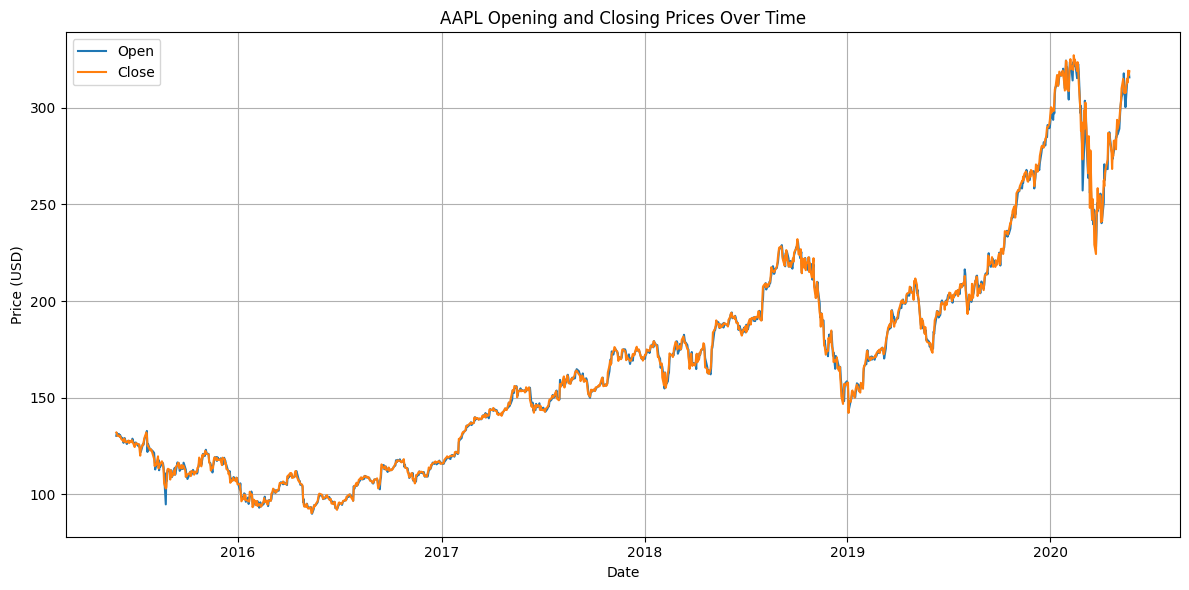

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(df["date"], df["open"], label="Open")
plt.plot(df["date"], df["close"], label="Close")

plt.title("AAPL Opening and Closing Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

### Result: Opening vs Closing Price
Opening and closing prices generally move together, while larger differences indicate stronger intraday price movements.

## Closing Price Distribution
Visualize the distribution of AAPL closing prices to understand their frequency and spread.

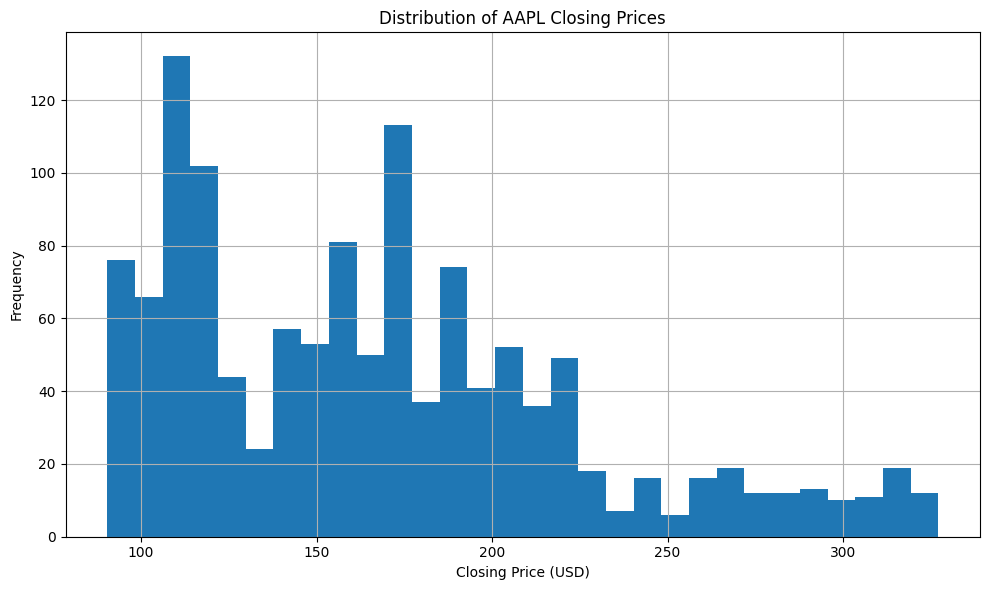

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(df["close"], bins=30)

plt.title("Distribution of AAPL Closing Prices")
plt.xlabel("Closing Price (USD)")
plt.ylabel("Frequency")

plt.grid(True)
plt.tight_layout()

plt.show()

### Result: Closing Price Distribution
The closing-price distribution shows variation in AAPL's price levels, reflecting changes in the stock price over time.

## Trading Volume Over Time
Analyze changes in AAPL trading volume throughout the observed period.

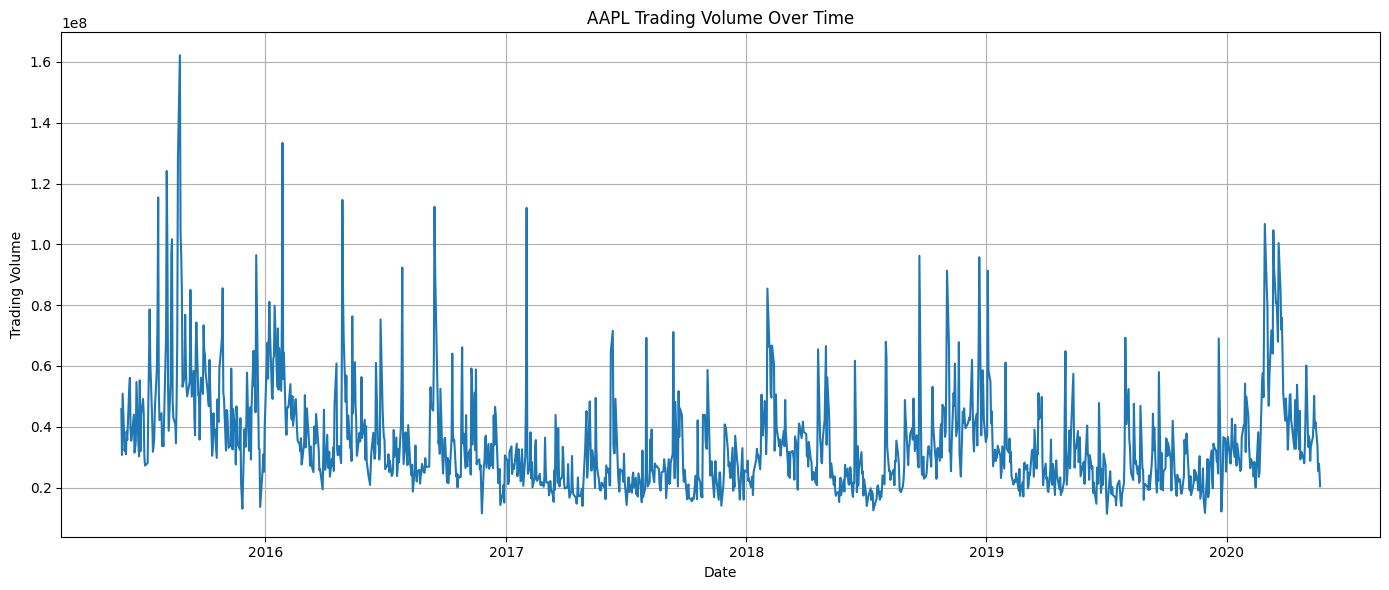

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(df["date"], df["volume"])

plt.title("AAPL Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Trading Volume")

plt.grid(True)
plt.tight_layout()

plt.show()

### Result: Trading Volume
Trading volume varies considerably, with spikes indicating periods of increased market activity.

## Daily Price Range
Calculate and visualize the difference between each day's high and low prices.

In [ ]:
# Range=High−Low
df["daily_range"] = df["high"] - df["low"]

In [ ]:
df[["date", "high", "low", "daily_range"]].head()

,date,high,low,daily_range
0,2015-05-27 00:00:00+00:00,132.260,130.05,2.210
1,2015-05-28 00:00:00+00:00,131.950,131.10,0.850
2,2015-05-29 00:00:00+00:00,131.450,129.90,1.550
3,2015-06-01 00:00:00+00:00,131.390,130.05,1.340
4,2015-06-02 00:00:00+00:00,130.655,129.32,1.335


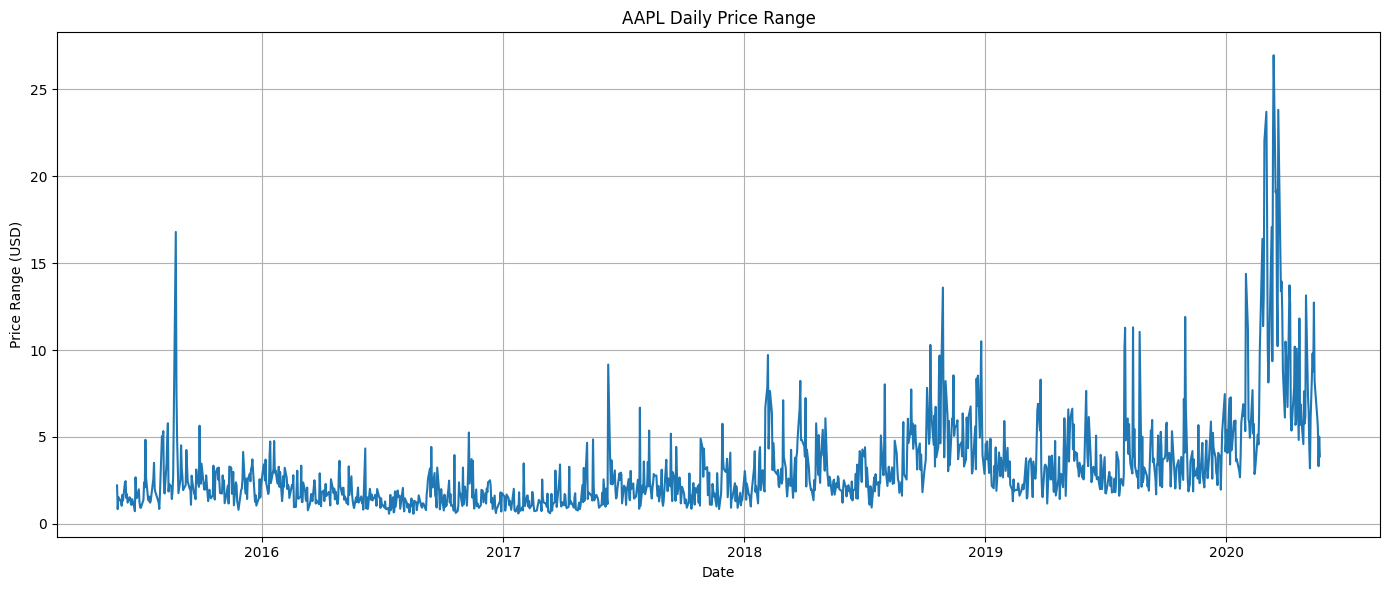

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(df["date"], df["daily_range"])

plt.title("AAPL Daily Price Range")
plt.xlabel("Date")
plt.ylabel("Price Range (USD)")

plt.grid(True)
plt.tight_layout()

plt.show()

### Result: Daily Price Range
The daily price range varies across trading days, indicating different levels of short-term price volatility.

## Correlation Between Price Variables
Examine the relationships between AAPL opening, high, low, closing prices, and trading volume.

In [ ]:
correlation = df[["open", "high", "low", "close", "volume"]].corr()

correlation

,open,high,low,close,volume
open,1.000000,0.999503,0.999488,0.999070,-0.138214
high,0.999503,1.000000,0.999146,0.999446,-0.124726
low,0.999488,0.999146,1.000000,0.999473,-0.152665
close,0.999070,0.999446,0.999473,1.000000,-0.139941
volume,-0.138214,-0.124726,-0.152665,-0.139941,1.000000


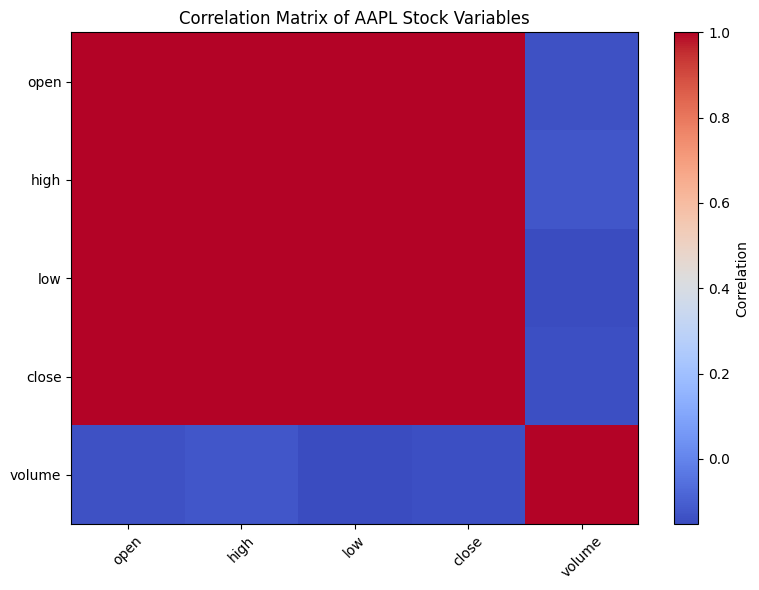

In [ ]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation, cmap="coolwarm", aspect="auto")

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.colorbar(label="Correlation")

plt.title("Correlation Matrix of AAPL Stock Variables")
plt.tight_layout()

plt.show()

### Result: Correlation Analysis
Opening, high, low, and closing prices show strong relationships because they represent prices from the same trading sessions.

#Time Series Trend Analysis

Analyze the overall movement of AAPL closing prices across the observation period.

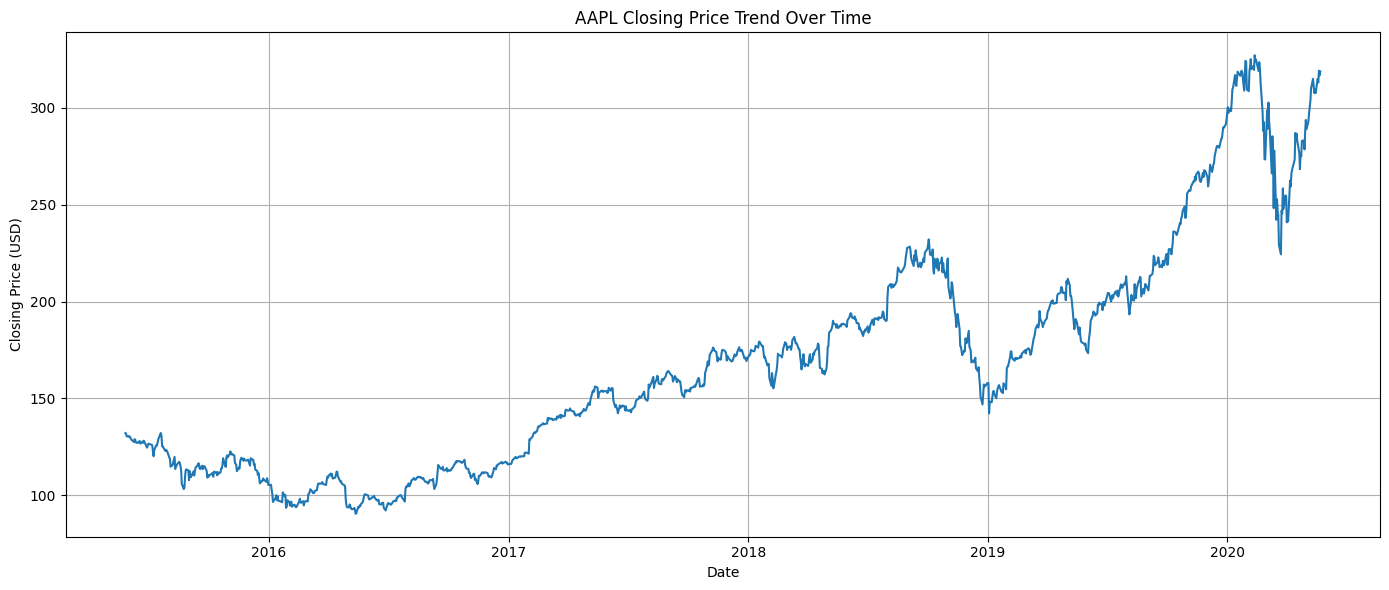

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(df["date"], df["close"])

plt.title("AAPL Closing Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")

plt.grid(True)
plt.tight_layout()

plt.show()

### Result: Overall Trend
The closing-price series shows an overall upward trend with noticeable short-term fluctuations.

## Daily Return Analysis
Calculate daily percentage returns to measure day-to-day changes in AAPL's closing price.

In [ ]:
df["daily_return"] = df["close"].pct_change() * 100

In [ ]:
df[["date", "close", "daily_return"]].head(10)

,date,close,daily_return
0,2015-05-27 00:00:00+00:00,132.045,NaN
1,2015-05-28 00:00:00+00:00,131.780,-0.200689
2,2015-05-29 00:00:00+00:00,130.280,-1.138261
3,2015-06-01 00:00:00+00:00,130.535,0.195732
4,2015-06-02 00:00:00+00:00,129.960,-0.440495
5,2015-06-03 00:00:00+00:00,130.120,0.123115
6,2015-06-04 00:00:00+00:00,129.360,-0.584076
7,2015-06-05 00:00:00+00:00,128.650,-0.548856
8,2015-06-08 00:00:00+00:00,127.800,-0.660707
9,2015-06-09 00:00:00+00:00,127.420,-0.297340


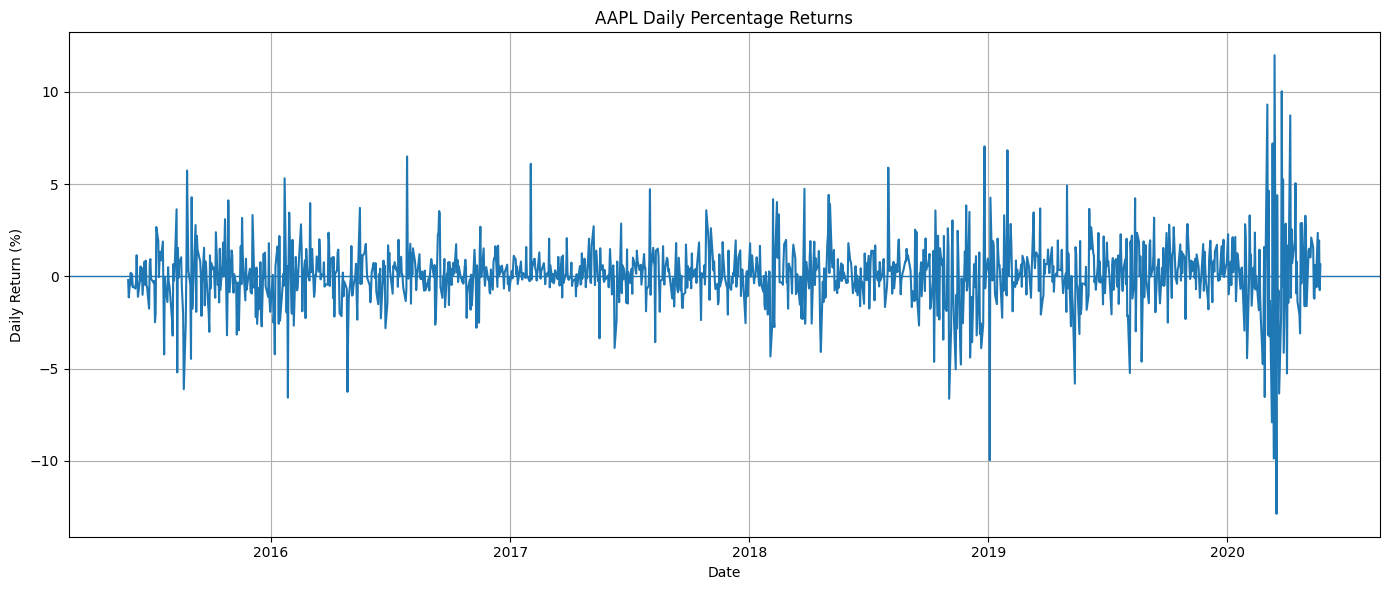

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(df["date"], df["daily_return"])

plt.title("AAPL Daily Percentage Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")

plt.axhline(0, linewidth=1)

plt.grid(True)
plt.tight_layout()

plt.show()

### Result: Daily Returns
Daily returns are mostly small, with occasional large positive or negative movements indicating higher volatility.

##Annual/Yearly Price Overview
Compare average AAPL closing prices across different years to observe long-term changes.

In [ ]:
df["year"] = df["date"].dt.year

In [ ]:
yearly_avg = df.groupby("year")["close"].mean()

yearly_avg

,close
year,
2015,117.832810
2016,104.604008
2017,150.551056
2018,189.053426
2019,208.255933
2020,291.787273


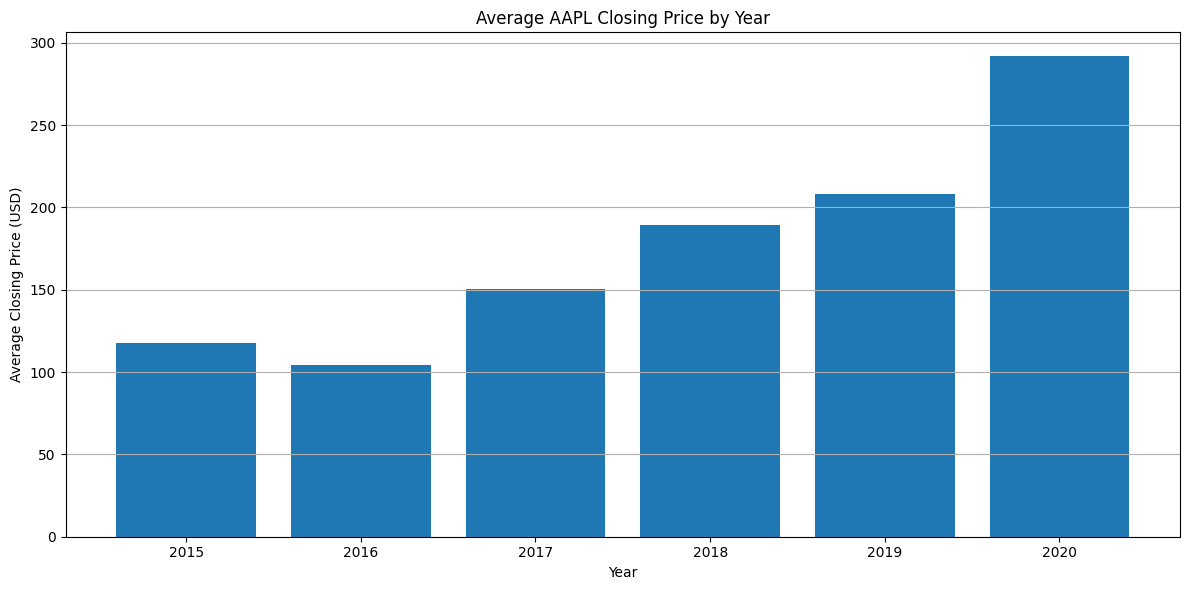

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(yearly_avg.index, yearly_avg.values)

plt.title("Average AAPL Closing Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Closing Price (USD)")

plt.grid(axis="y")
plt.tight_layout()

plt.show()

### Result: Annual Price Overview
Yearly average prices show changes in AAPL's overall price level and support the observed long-term upward trend.

#Seasonality Analysis

Seasonality means a pattern that repeats at a regular interval.

## Monthly Average Closing Prices
Calculate the average closing price for each calendar month to examine monthly patterns.

In [ ]:
monthly_avg = df.groupby(df["date"].dt.month)["close"].mean()

monthly_avg

,close
date,
1,173.562647
2,175.183385
3,172.618807
4,179.163495
5,178.831085
6,149.627570
7,154.340952
8,160.099196
9,162.655594


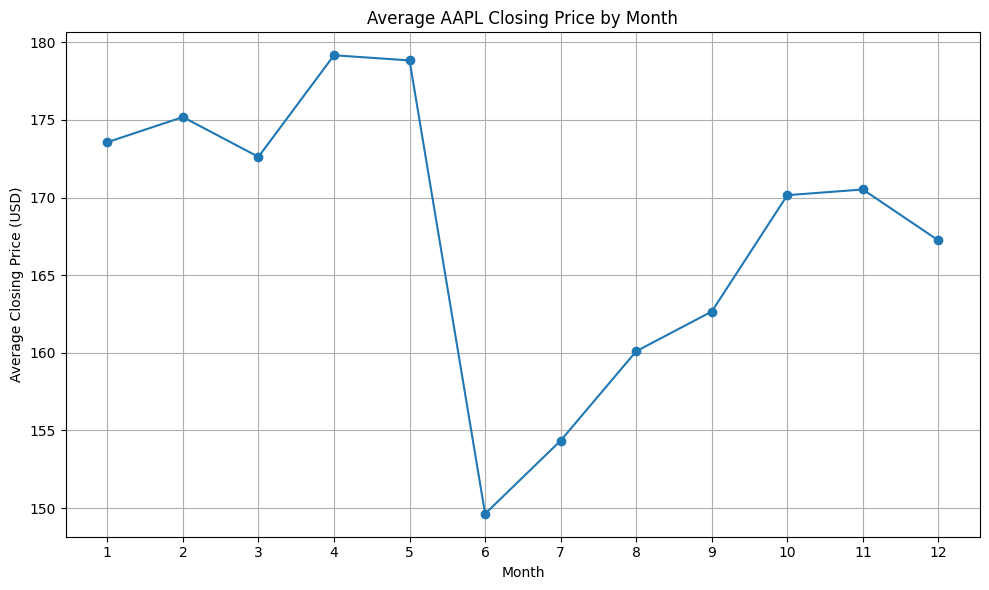

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(monthly_avg.index, monthly_avg.values, marker="o")

plt.title("Average AAPL Closing Price by Month")
plt.xlabel("Month")
plt.ylabel("Average Closing Price (USD)")

plt.xticks(range(1, 13))

plt.grid(True)
plt.tight_layout()

plt.show()

### Result: Monthly Average Prices
Monthly average prices vary across months, but price levels alone do not provide strong evidence of seasonality.

## Monthly Returns
Calculate average monthly returns to provide a clearer view of recurring calendar-month patterns.

In [ ]:
# monthly closing prices
monthly_close = df.set_index("date")["close"].resample("ME").last()

In [ ]:
# monthly percentage returns
monthly_returns = monthly_close.pct_change() * 100

In [ ]:
# creating a month number
monthly_returns_df = monthly_returns.to_frame(name="monthly_return")

monthly_returns_df["month"] = monthly_returns_df.index.month

In [ ]:
# average return for each calendar month
seasonal_returns = monthly_returns_df.groupby("month")["monthly_return"].mean()

seasonal_returns

,monthly_return
month,
1,1.420635
2,2.191413
3,2.902276
4,1.135986
5,4.345885
6,-0.320773
7,3.885125
8,4.528891
9,0.962054


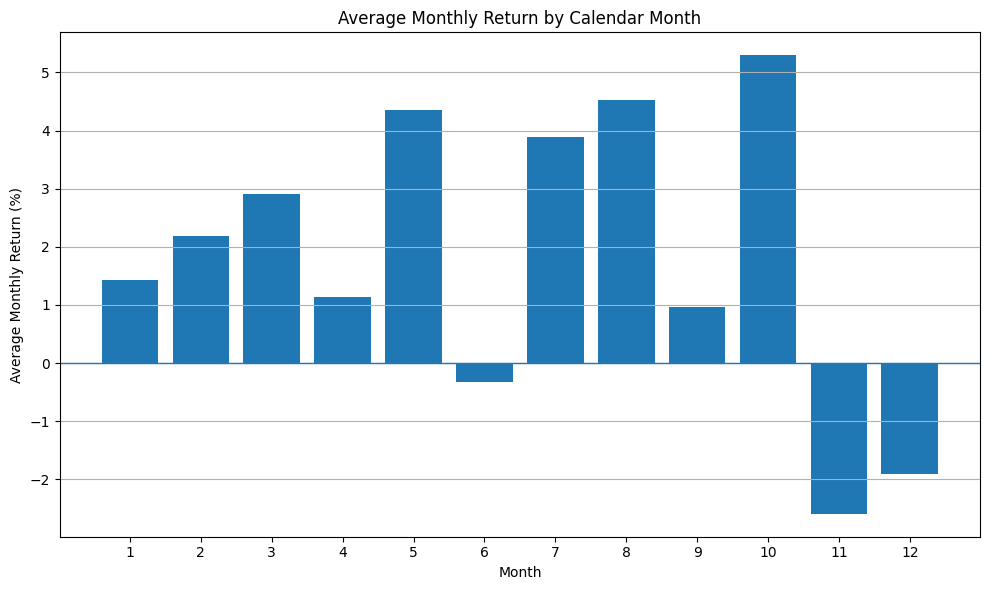

In [ ]:
plt.figure(figsize=(10, 6))

plt.bar(seasonal_returns.index, seasonal_returns.values)

plt.title("Average Monthly Return by Calendar Month")
plt.xlabel("Month")
plt.ylabel("Average Monthly Return (%)")

plt.xticks(range(1, 13))

plt.axhline(0, linewidth=1)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

### Result: Monthly Returns
Monthly returns show variation between months and can be used to examine possible recurring seasonal patterns.

#Anomaly Detection

An anomaly is an observation that is unusually different from the normal behavior of the dataset.

## Calculating IQR
Use the Interquartile Range method to establish lower and upper boundaries for potential anomalies.

In [ ]:
Q1 = df["daily_return"].quantile(0.25)
Q3 = df["daily_return"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: -0.6463040980467238
Q3: 0.9338596322326032
IQR: 1.580163730279327


In [ ]:
# Anomaly Boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -3.016549693465714
Upper Bound: 3.3041052276515934


## Identification of Anomalies
Identify observations whose daily returns fall outside the calculated IQR boundaries.

In [ ]:
anomalies = df[
    (df["daily_return"] < lower_bound) |
    (df["daily_return"] > upper_bound)
].copy()

In [ ]:
anomalies[["date", "close", "daily_return"]]

,date,close,daily_return
39,2015-07-22 00:00:00+00:00,125.22,-4.229446
48,2015-08-04 00:00:00+00:00,114.64,-3.208376
52,2015-08-10 00:00:00+00:00,119.72,3.635734
53,2015-08-11 00:00:00+00:00,113.49,-5.203809
61,2015-08-21 00:00:00+00:00,105.76,-6.116289
...,...,...,...
1218,2020-03-27 00:00:00+00:00,247.74,-4.140226
1221,2020-04-01 00:00:00+00:00,240.91,-5.261709
1224,2020-04-06 00:00:00+00:00,262.47,8.723748
1229,2020-04-14 00:00:00+00:00,287.05,5.050320


In [ ]:
print("Number of anomalies:", len(anomalies))

Number of anomalies: 89


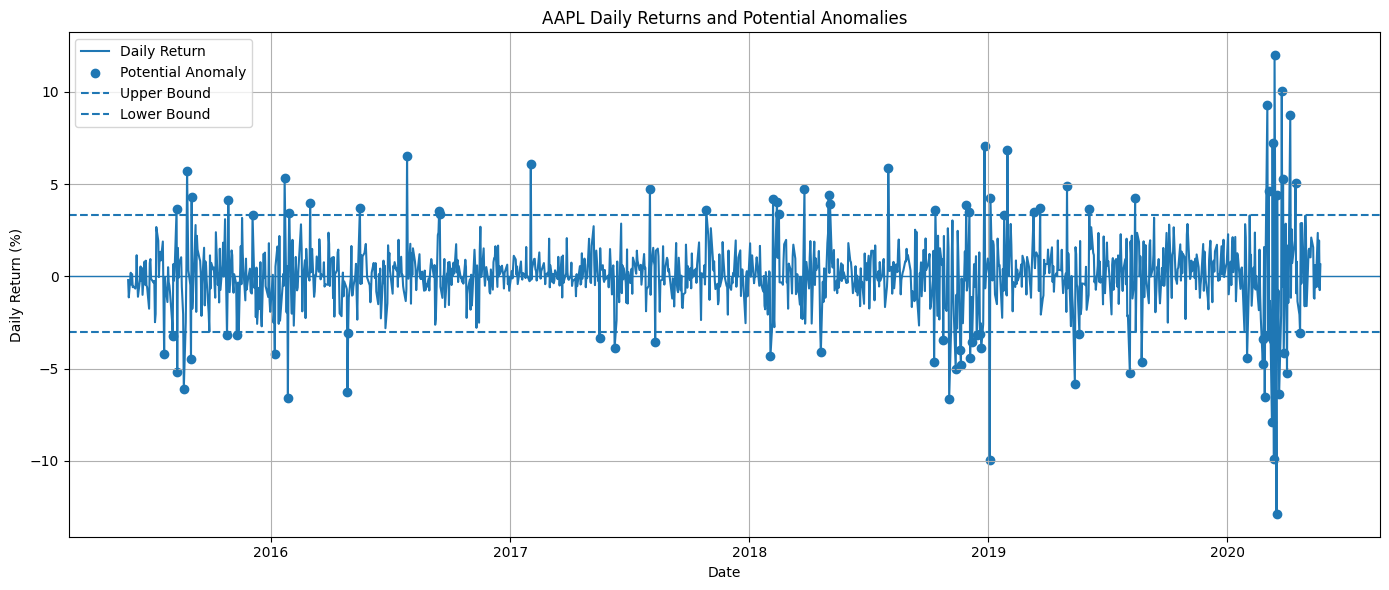

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(
    df["date"],
    df["daily_return"],
    label="Daily Return"
)

plt.scatter(
    anomalies["date"],
    anomalies["daily_return"],
    label="Potential Anomaly"
)

plt.axhline(
    upper_bound,
    linestyle="--",
    label="Upper Bound"
)

plt.axhline(
    lower_bound,
    linestyle="--",
    label="Lower Bound"
)

plt.axhline(0, linewidth=1)

plt.title("AAPL Daily Returns and Potential Anomalies")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

### Result: Anomaly Detection
IQR-based analysis identifies trading days with unusually large daily returns compared with the normal return range.

## Examine the Largest Movements
Examine the largest positive and negative daily returns in the dataset.

In [ ]:
# Largest INcrease
largest_increases = df.nlargest(
    10,
    "daily_return"
)[["date", "close", "daily_return"]]

largest_increases

,date,close,daily_return
1208,2020-03-13 00:00:00+00:00,277.97,11.980824
1215,2020-03-24 00:00:00+00:00,246.88,10.032536
1199,2020-03-02 00:00:00+00:00,298.81,9.310067
1224,2020-04-06 00:00:00+00:00,262.47,8.723748
1205,2020-03-10 00:00:00+00:00,285.34,7.202164
903,2018-12-26 00:00:00+00:00,157.17,7.042158
926,2019-01-30 00:00:00+00:00,165.25,6.833463
295,2016-07-27 00:00:00+00:00,102.95,6.496328
425,2017-02-01 00:00:00+00:00,128.75,6.098063
802,2018-08-01 00:00:00+00:00,201.50,5.891008


In [ ]:
# Largest Decrease
largest_decreases = df.nsmallest(
    10,
    "daily_return"
)[["date", "close", "daily_return"]]

largest_decreases

,date,close,daily_return
1209,2020-03-16 00:00:00+00:00,242.21,-12.864698
908,2019-01-03 00:00:00+00:00,142.19,-9.960740
1207,2020-03-12 00:00:00+00:00,248.23,-9.875467
1204,2020-03-09 00:00:00+00:00,266.17,-7.909214
868,2018-11-02 00:00:00+00:00,207.48,-6.633066
169,2016-01-27 00:00:00+00:00,93.42,-6.570657
1197,2020-02-27 00:00:00+00:00,273.52,-6.536819
1213,2020-03-20 00:00:00+00:00,229.24,-6.348558
232,2016-04-27 00:00:00+00:00,97.82,-6.257786
61,2015-08-21 00:00:00+00:00,105.76,-6.116289


### Result: Largest Price Movements
The largest positive and negative returns represent the most significant short-term price movements in the dataset.

#Moving Average Analysis

A moving average smooths daily stock-price fluctuations so we can see the underlying trend more clearly.

## 7-Day Moving Average
Calculate a 7-day moving average to smooth short-term changes in AAPL closing prices.

In [ ]:
df["MA_7"] = df["close"].rolling(window=7).mean()

In [ ]:
df[["date", "close", "MA_7"]].head(10)

,date,close,MA_7
0,2015-05-27 00:00:00+00:00,132.045,NaN
1,2015-05-28 00:00:00+00:00,131.780,NaN
2,2015-05-29 00:00:00+00:00,130.280,NaN
3,2015-06-01 00:00:00+00:00,130.535,NaN
4,2015-06-02 00:00:00+00:00,129.960,NaN
5,2015-06-03 00:00:00+00:00,130.120,NaN
6,2015-06-04 00:00:00+00:00,129.360,130.582857
7,2015-06-05 00:00:00+00:00,128.650,130.097857
8,2015-06-08 00:00:00+00:00,127.800,129.529286
9,2015-06-09 00:00:00+00:00,127.420,129.120714


### Result: 7-Day Moving Average
The 7-day moving average smooths short-term fluctuations while remaining responsive to recent price changes.


## 30-Day Moving Average
Calculate a 30-day moving average to observe the broader price trend.

In [ ]:
df["MA_30"] = df["close"].rolling(window=30).mean()

In [ ]:
df[["date", "close", "MA_30"]].head(35)

,date,close,MA_30
0,2015-05-27 00:00:00+00:00,132.045,NaN
1,2015-05-28 00:00:00+00:00,131.780,NaN
2,2015-05-29 00:00:00+00:00,130.280,NaN
3,2015-06-01 00:00:00+00:00,130.535,NaN
4,2015-06-02 00:00:00+00:00,129.960,NaN
5,2015-06-03 00:00:00+00:00,130.120,NaN
6,2015-06-04 00:00:00+00:00,129.360,NaN
7,2015-06-05 00:00:00+00:00,128.650,NaN
8,2015-06-08 00:00:00+00:00,127.800,NaN
9,2015-06-09 00:00:00+00:00,127.420,NaN


### Result: 30-Day Moving Average
The 30-day moving average provides a smoother representation of the broader price trend.

##Main Moving Average Visualization

Compare the actual closing price with the 7-day and 30-day moving averages.

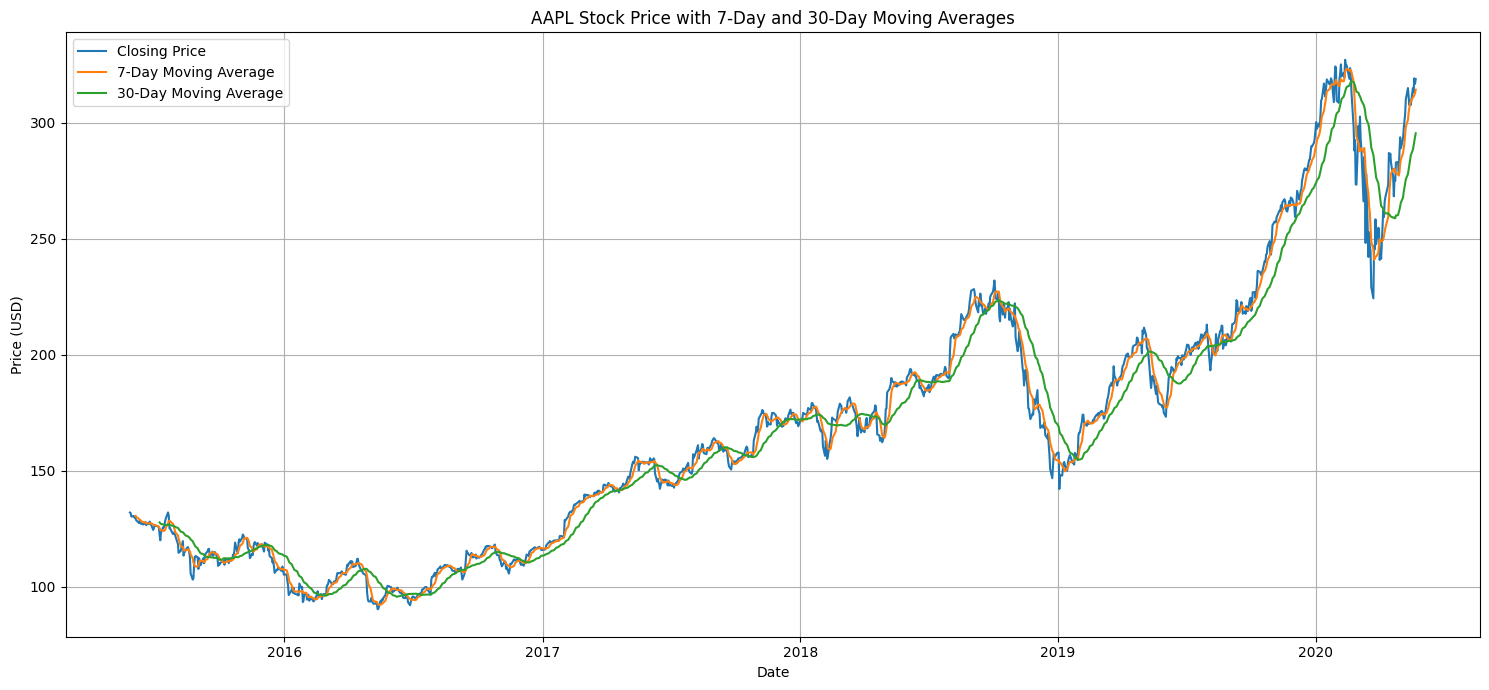

In [ ]:
plt.figure(figsize=(15, 7))

plt.plot(
    df["date"],
    df["close"],
    label="Closing Price"
)

plt.plot(
    df["date"],
    df["MA_7"],
    label="7-Day Moving Average"
)

plt.plot(
    df["date"],
    df["MA_30"],
    label="30-Day Moving Average"
)

plt.title("AAPL Stock Price with 7-Day and 30-Day Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Result: Moving Average Comparison
The 7-day average responds faster to price changes, while the 30-day average better represents the broader trend.

##Compare Recent Price With Moving Averages
Examine recent AAPL prices alongside their moving averages for clearer trend interpretation.

In [ ]:
df[[
    "date",
    "close",
    "MA_7",
    "MA_30"
]].tail(10)

,date,close,MA_7,MA_30
1248,2020-05-11 00:00:00+00:00,315.01,301.328571,277.950333
1249,2020-05-12 00:00:00+00:00,311.41,304.520000,279.837000
1250,2020-05-13 00:00:00+00:00,307.65,306.590000,281.615667
1251,2020-05-14 00:00:00+00:00,309.54,308.301429,283.903333
1252,2020-05-15 00:00:00+00:00,307.71,309.312857,285.996000
1253,2020-05-18 00:00:00+00:00,314.96,310.915714,288.447667
1254,2020-05-19 00:00:00+00:00,313.14,311.345714,290.136667
1255,2020-05-20 00:00:00+00:00,319.23,311.948571,292.130000
1256,2020-05-21 00:00:00+00:00,316.85,312.725714,293.822667
1257,2020-05-22 00:00:00+00:00,318.89,314.331429,295.519333


## Moving Average Relationship
Compare the 7-day and 30-day moving averages to observe changes in short- and medium-term momentum.

In [ ]:
df["MA_difference"] = df["MA_7"] - df["MA_30"]

In [ ]:
df[[
    "date",
    "MA_7",
    "MA_30",
    "MA_difference"
]].tail(10)

,date,MA_7,MA_30,MA_difference
1248,2020-05-11 00:00:00+00:00,301.328571,277.950333,23.378238
1249,2020-05-12 00:00:00+00:00,304.520000,279.837000,24.683000
1250,2020-05-13 00:00:00+00:00,306.590000,281.615667,24.974333
1251,2020-05-14 00:00:00+00:00,308.301429,283.903333,24.398095
1252,2020-05-15 00:00:00+00:00,309.312857,285.996000,23.316857
1253,2020-05-18 00:00:00+00:00,310.915714,288.447667,22.468048
1254,2020-05-19 00:00:00+00:00,311.345714,290.136667,21.209048
1255,2020-05-20 00:00:00+00:00,311.948571,292.130000,19.818571
1256,2020-05-21 00:00:00+00:00,312.725714,293.822667,18.903048
1257,2020-05-22 00:00:00+00:00,314.331429,295.519333,18.812095


#Cleaner visualization

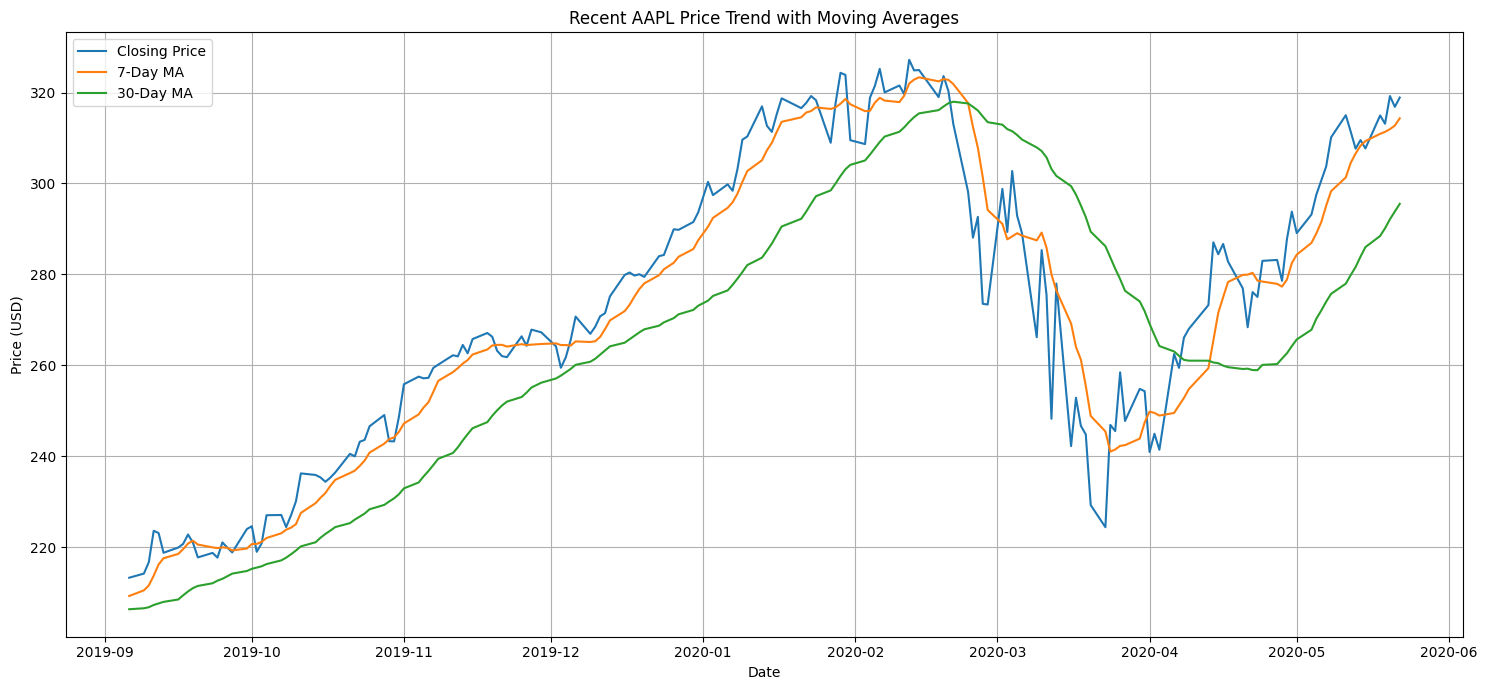

In [ ]:
recent = df.tail(180)

plt.figure(figsize=(15, 7))

plt.plot(
    recent["date"],
    recent["close"],
    label="Closing Price"
)

plt.plot(
    recent["date"],
    recent["MA_7"],
    label="7-Day MA"
)

plt.plot(
    recent["date"],
    recent["MA_30"],
    label="30-Day MA"
)

plt.title("Recent AAPL Price Trend with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

#Forecasting with Prophet and ARIMA

##Prepare the forecasting dataset
Prepare the date and closing-price columns in the format required for time-series forecasting.




In [ ]:
# Remove timezone information from the date column
df["date"] = pd.to_datetime(df["date"]).dt.tz_localize(None)

In [ ]:
# Create a clean dataframe
forecast_df = df[["date", "close"]].copy()

forecast_df = forecast_df.rename(
    columns={
        "date": "ds",
        "close": "y"
    }
)

forecast_df.head()

,ds,y
0,2015-05-27,132.045
1,2015-05-28,131.780
2,2015-05-29,130.280
3,2015-06-01,130.535
4,2015-06-02,129.960


## Train-Test Split
Split the chronological dataset into training and testing periods for evaluating the forecasting models.

In [ ]:
split_index = int(len(forecast_df) * 0.8)

train = forecast_df.iloc[:split_index].copy()
test = forecast_df.iloc[split_index:].copy()

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 1006
Testing observations: 252


In [ ]:
# Check the dates
print("Training period:")
print(train["ds"].min(), "to", train["ds"].max())

print("\nTesting period:")
print(test["ds"].min(), "to", test["ds"].max())

Training period:
2015-05-27 00:00:00 to 2019-05-23 00:00:00

Testing period:
2019-05-24 00:00:00 to 2020-05-22 00:00:00


Installaling Prophet

In [ ]:
!pip install prophet

In [ ]:
from prophet import Prophet

Building the Prophet model

In [ ]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

prophet_model.fit(train)

## Creating Future Dates
Generate future timestamps required by the Prophet model to produce forecasts.

In [ ]:
future = prophet_model.make_future_dataframe(
    periods=len(test),
    freq="B"
)

## Prophet Forecast
Visualize the historical data together with the Prophet forecast and its uncertainty range.

In [ ]:
# generating the forecast
prophet_forecast = prophet_model.predict(future)

In [ ]:
prophet_forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail()

,ds,yhat,yhat_lower,yhat_upper
1253,2020-05-05,169.697144,146.871760,192.269587
1254,2020-05-06,169.764784,148.911429,190.440796
1255,2020-05-07,169.373501,146.612805,191.134993
1256,2020-05-08,169.031051,146.429121,191.417135
1257,2020-05-11,168.755238,146.077127,191.450688


##Plot Prophet forecast

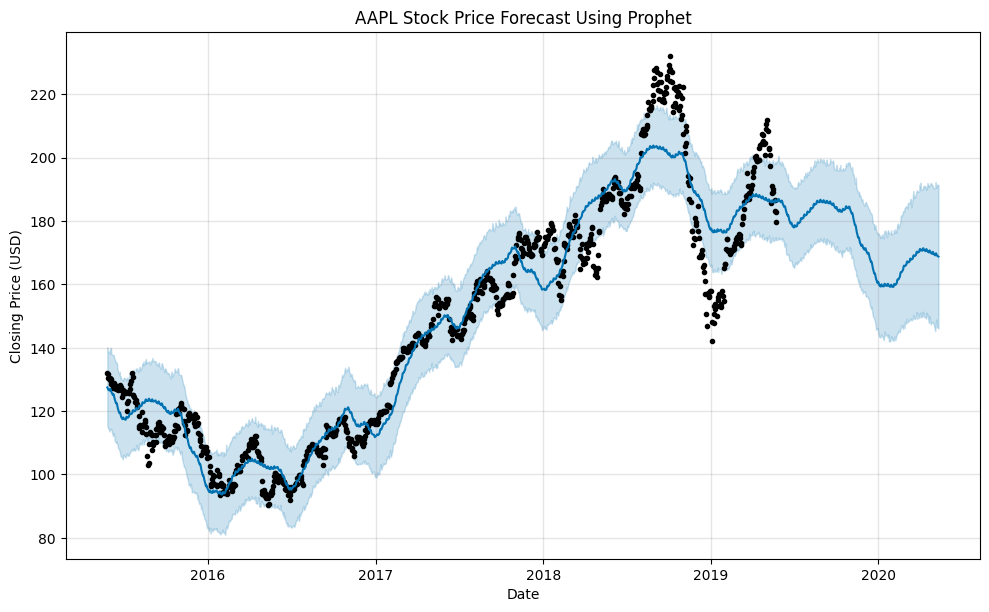

In [ ]:
fig = prophet_model.plot(prophet_forecast)

plt.title("AAPL Stock Price Forecast Using Prophet")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")

plt.show()

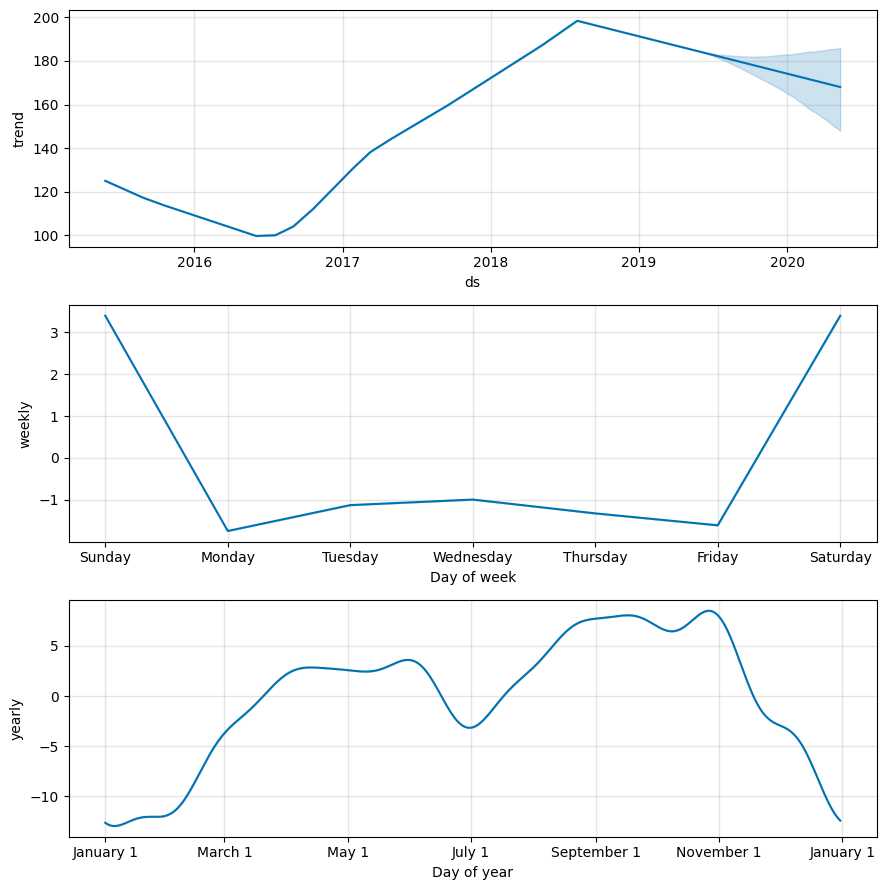

In [ ]:
fig = prophet_model.plot_components(prophet_forecast)

plt.show()

### Result: Prophet Forecast
Prophet captures the general time-series pattern and provides forecasts for the unseen test period.

##Extract Prophet predictions for the test period

In [ ]:
prophet_test = prophet_forecast[
    prophet_forecast["ds"].isin(test["ds"])
][["ds", "yhat"]].copy()

In [ ]:
# Merge actual and predicted values
prophet_results = test.merge(
    prophet_test,
    on="ds"
)

prophet_results.head()

,ds,y,yhat
0,2019-05-24,178.97,186.177325
1,2019-05-28,178.23,186.787991
2,2019-05-29,177.38,186.926780
3,2019-05-30,178.30,186.587445
4,2019-05-31,175.07,186.273957


##Evaluating Prophet

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_prophet = mean_absolute_error(
    prophet_results["y"],
    prophet_results["yhat"]
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        prophet_results["y"],
        prophet_results["yhat"]
    )
)

mape_prophet = np.mean(
    np.abs(
        (prophet_results["y"] - prophet_results["yhat"])
        / prophet_results["y"]
    )
) * 100

print("Prophet MAE:", mae_prophet)
print("Prophet RMSE:", rmse_prophet)
print("Prophet MAPE:", mape_prophet, "%")

Prophet MAE: 75.20198942159793
Prophet RMSE: 90.26208492967547
Prophet MAPE: 27.581832597698273 %


#ARIMA(AutoRegressive Integrated Moving Average)

## ARIMA Model
Train an ARIMA model to forecast AAPL closing prices based on historical price patterns.

In [ ]:
arima_train = train.set_index("ds")["y"]
arima_test = test.set_index("ds")["y"]

Install/import statsmodels

In [ ]:
!pip install statsmodels

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

##Training ARIMA

In [ ]:
# Keep the actual dates separately
train_dates = train["ds"].copy()
test_dates = test["ds"].copy()

# Use a simple numeric index for ARIMA
arima_train = train["y"].reset_index(drop=True)
arima_test = test["y"].reset_index(drop=True)

print("Training observations:", len(arima_train))
print("Testing observations:", len(arima_test))
print(arima_train.head())

Training observations: 1006
Testing observations: 252
0    132.045
1    131.780
2    130.280
3    130.535
4    129.960
Name: y, dtype: float64


In [ ]:
arima_model = ARIMA(
    arima_train,
    order=(5, 1, 0)
)

arima_fitted = arima_model.fit()

print(arima_fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1006
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -2314.704
Date:                Mon, 28 Sep 2026   AIC                           4641.407
Time:                        18:45:51   BIC                           4670.884
Sample:                             0   HQIC                          4652.608
                               - 1006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0143      0.023      0.631      0.528      -0.030       0.059
ar.L2         -0.0355      0.025     -1.427      0.153      -0.084       0.013
ar.L3         -0.0206      0.023     -0.885      0.3

## Generating ARIMA Forecast
Generate predictions for the same test period used to evaluate the Prophet model.

In [ ]:
arima_forecast_values = arima_fitted.forecast(
    steps=len(arima_test)
)

print(arima_forecast_values.head())

1006    179.584360
1007    179.619057
1008    179.760449
1009    179.609243
1010    179.500806
Name: predicted_mean, dtype: float64


In [ ]:
arima_forecast = pd.Series(
    arima_forecast_values.to_numpy(),
    index=test_dates
)

print(arima_forecast.head())

ds
2019-05-24    179.584360
2019-05-28    179.619057
2019-05-29    179.760449
2019-05-30    179.609243
2019-05-31    179.500806
dtype: float64


### Result: ARIMA Forecast
ARIMA generates forecasts based on the historical time-series behavior of the closing price.

##Evaluating ARIMA

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_arima = mean_absolute_error(
    arima_test,
    arima_forecast_values
)

rmse_arima = np.sqrt(
    mean_squared_error(
        arima_test,
        arima_forecast_values
    )
)

mape_arima = np.mean(
    np.abs(
        (arima_test.to_numpy() - arima_forecast_values.to_numpy())
        / arima_test.to_numpy()
    )
) * 100

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)
print("ARIMA MAPE:", mape_arima, "%")

ARIMA MAE: 72.55503554760762
ARIMA RMSE: 84.3765301028509
ARIMA MAPE: 26.642318200193376 %


#Model Evaluation and Comparison

##Comparing Prophet vs ARIMA

In [ ]:
model_comparison = pd.DataFrame({
    "Model": ["Prophet", "ARIMA"],
    "MAE": [mae_prophet, mae_arima],
    "RMSE": [rmse_prophet, rmse_arima],
    "MAPE (%)": [mape_prophet, mape_arima]
})

model_comparison

,Model,MAE,RMSE,MAPE (%)
0,Prophet,75.201989,90.262085,27.581833
1,ARIMA,72.555036,84.376530,26.642318


### Result: Model Evaluation
MAE, RMSE, and MAPE were used to compare the forecasting errors of Prophet and ARIMA.

#Final Forecast Visualization

##Actual vs Prophet vs ARIMA

Visualize the actual AAPL prices alongside the Prophet and ARIMA forecasts for the test period.

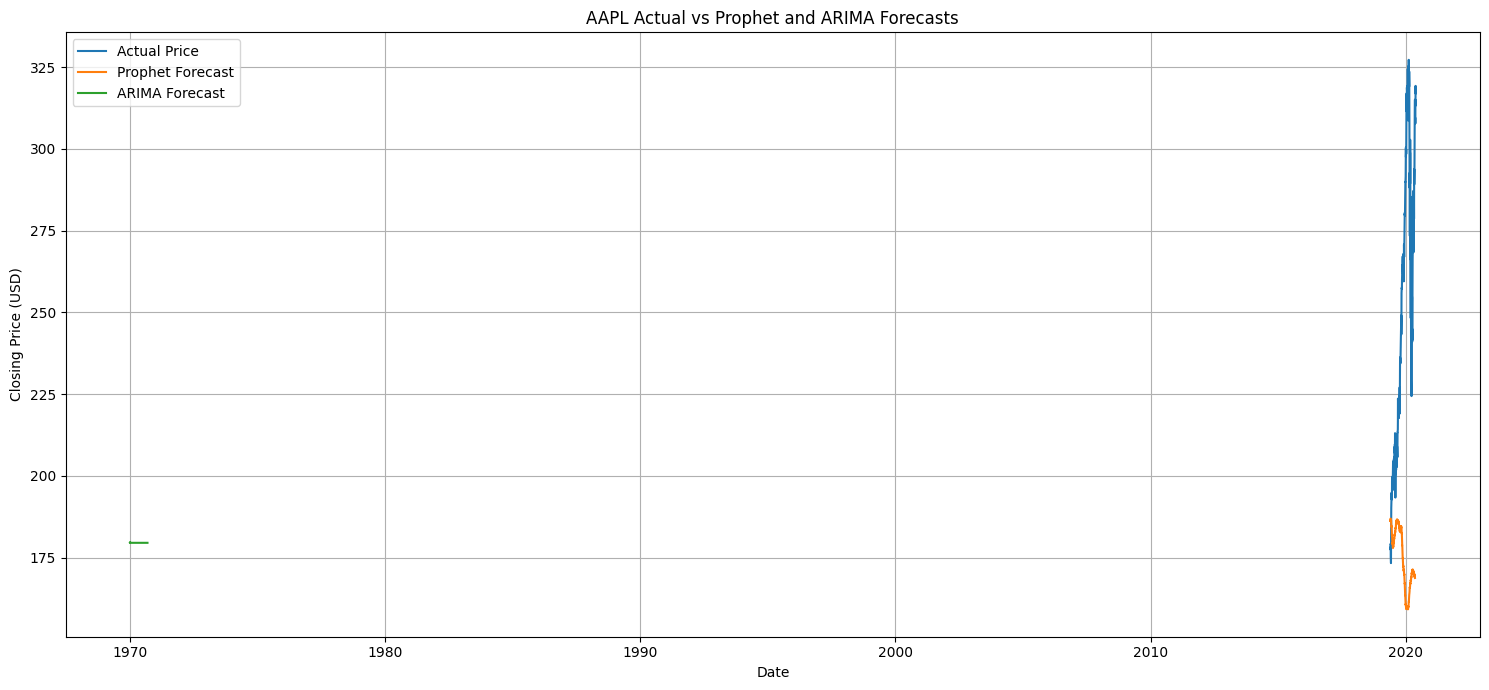

In [ ]:
plt.figure(figsize=(15, 7))

plt.plot(
    test["ds"],
    test["y"],
    label="Actual Price"
)

plt.plot(
    prophet_results["ds"],
    prophet_results["yhat"],
    label="Prophet Forecast"
)

plt.plot(
    arima_test.index,
    arima_forecast,
    label="ARIMA Forecast"
)

plt.title("AAPL Actual vs Prophet and ARIMA Forecasts")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Result: Forecast Comparison
The model with lower error metrics provides more accurate predictions for the test period of this dataset.

#Business Insights
- Trend analysis helps understand changes in overall stock price levels.
- Moving averages provide a clearer view of short- and medium-term trends.
- Anomaly detection can highlight periods of unusual market activity.
- Volume analysis helps identify periods of increased trading activity.
- Forecasting models can support data-driven market scenario planning.
- Combining trend, volatility, volume, and forecasting analysis provides a broader view of market behavior.

#Recommendations
- Monitor moving averages to track changes in price trends.
- Monitor unusually large daily returns for potential anomalies.
- Track trading-volume spikes alongside major price movements.
- Update forecasting models regularly as new data becomes available.
- Compare multiple forecasting models before relying on predictions.

#Conclusion
- Identified the overall upward trend in AAPL closing prices.
- Observed short-term fluctuations and varying market volatility.
- Detected unusual daily price movements using IQR-based analysis.
- Used 7-day and 30-day moving averages to smooth price trends.
- Examined possible monthly seasonal patterns using monthly returns.
- Applied Prophet and ARIMA for future price forecasting.
- Evaluated forecasting performance using MAE, RMSE, and MAPE.